#### imports

In [ ]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import requests
import time # Import the time library

import os
import glob

from zipfile import * #package for unzipping zip files

#### file download from Bureau of Transportation Statistics

The Bureau of Transportation Statistics (BTS), part of the Department of Transportation (DOT) is the preeminent source of statistics on commercial aviation

In [2]:

# --- Configuration ---
# Example years and months
years = [2025] # e.g., 2022 and 2023
months = [1]    # 1 through 12
path = './data/'    # Make sure this directory exists!

# Create the directory if it doesn't exist
if not os.path.exists(path):
    os.makedirs(path)

# It's good practice to set a User-Agent so the server knows who you are
headers = {
    'User-Agent': 'My Data Science Project (contact@example.com)'
}

# --- Main Loop ---
for year in years:
    for month in months:
        zip_file = f'On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip'
        url = f'https://transtats.bts.gov/PREZIP/{zip_file}'
        
        print(f"Attempting to download: {url}")
        
        try:
            # Use a session object for potential performance improvements and to persist headers
            # with requests.get(url, headers=headers, stream=True, verify=False, timeout=30) as response:
            with requests.get(url, stream=True, verify=False, timeout=30) as response:
                # Check if the request was successful
                if response.status_code == 200:
                    # Save the file
                    with open(path + zip_file, 'wb') as f:
                        for chunk in response.iter_content(chunk_size=8192):
                            f.write(chunk)
                    print(f"SUCCESS: Saved {zip_file}")
                    with ZipFile(path+zip_file, 'r') as zip_ref:
                        zip_ref.extractall(path)
                    print(f"SUCCESS: Extracted files from {zip_file}")
                else:
                # If not successful, print the reason
                    print(f"FAILED: Status code {response.status_code} for {zip_file}. Reason: {response.reason}")

        except requests.exceptions.RequestException as e:
            print(f"ERROR: An exception occurred for {url}: {e}")

        # BE POLITE! Wait for a second between requests to avoid being rate-limited.
        time.sleep(1)

print("SUCCESS: Download process finished.")

Attempting to download: https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_1.zip


/Users/matthiasmotl/opt/anaconda3/envs/experiment_tracking/lib/python3.9/site-packages/urllib3/connectionpool.py:1064: InsecureRequestWarning: Unverified HTTPS request is being made to host 'transtats.bts.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


SUCCESS: Saved On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_1.zip
SUCCESS: Extracted files from On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_1.zip
SUCCESS: Download process finished.


#### concatinate csv to single df

In [6]:
# Find all CSV files in the ./data directory
csv_files = glob.glob(os.path.join(path, "*.csv"))

# Concatenate all CSV files into a single DataFrame
df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"Concatenated {len(csv_files)} CSV files into a dataframe with {len(df_all)} rows.")

/var/folders/2p/knkmky2x69s7jl6b1s6y8s3r0000gn/T/ipykernel_58221/2935469233.py:5: DtypeWarning: Columns (76,77,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)


Concatenated 1 CSV files into a dataframe with 539747 rows.


In [7]:
f'millions of rows: {len(df) / 1_000_000:.2f}'

'millions of rows: 0.54'

In [8]:
df.head()


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2025,1,1,1,3,2025-01-01,AA,19805,AA,N104NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,2,4,2025-01-02,AA,19805,AA,N110AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,3,5,2025-01-03,AA,19805,AA,N106NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,4,6,2025-01-04,AA,19805,AA,N117AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,5,7,2025-01-05,AA,19805,AA,N104NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.tail()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
539742,2025,1,1,5,7,2025-01-05,NK,20416,NK,N682NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539743,2025,1,1,6,1,2025-01-06,NK,20416,NK,N684NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539744,2025,1,1,7,2,2025-01-07,NK,20416,NK,N662NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539745,2025,1,1,8,3,2025-01-08,NK,20416,NK,N684NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
539746,2025,1,1,9,4,2025-01-09,NK,20416,NK,N739NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.columns

Index(['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate',
       'Reporting_Airline', 'DOT_ID_Reporting_Airline',
       'IATA_CODE_Reporting_Airline', 'Tail_Number',
       ...
       'Div4TailNum', 'Div5Airport', 'Div5AirportID', 'Div5AirportSeqID',
       'Div5WheelsOn', 'Div5TotalGTime', 'Div5LongestGTime', 'Div5WheelsOff',
       'Div5TailNum', 'Unnamed: 109'],
      dtype='object', length=110)

In [14]:
# Columns from downloaded file that are to be kept

columns_to_keep = [
                'DayofMonth',
                'DayOfWeek',
                'FlightDate',
                'DepTime',
                'CRSDepTime',
                'DepDelay',
                'ArrTime',
                'CRSArrTime',
                'ArrDelay',
                'Reporting_Airline',
                'Tail_Number',
                'Flight_Number_Reporting_Airline',
                'Origin',
                'Dest',
                'AirTime',
                'Distance',
                'Cancelled',
                'Diverted'
]

In [15]:
df = df[columns_to_keep]

In [16]:
df.columns

Index(['DayofMonth', 'DayOfWeek', 'FlightDate', 'DepTime', 'CRSDepTime',
       'DepDelay', 'ArrTime', 'CRSArrTime', 'ArrDelay', 'Reporting_Airline',
       'Tail_Number', 'Flight_Number_Reporting_Airline', 'Origin', 'Dest',
       'AirTime', 'Distance', 'Cancelled', 'Diverted'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539747 entries, 0 to 539746
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   DayofMonth                       539747 non-null  int64  
 1   DayOfWeek                        539747 non-null  int64  
 2   FlightDate                       539747 non-null  object 
 3   DepTime                          523861 non-null  float64
 4   CRSDepTime                       539747 non-null  int64  
 5   DepDelay                         523824 non-null  float64
 6   ArrTime                          523167 non-null  float64
 7   CRSArrTime                       539747 non-null  int64  
 8   ArrDelay                         522269 non-null  float64
 9   Reporting_Airline                539747 non-null  object 
 10  Tail_Number                      537217 non-null  object 
 11  Flight_Number_Reporting_Airline  539747 non-null  int64  
 12  Or

In [18]:
df.ArrDelay.describe()


count    522269.000000
mean          3.756614
std          56.850884
min         -87.000000
25%         -18.000000
50%          -8.000000
75%           7.000000
max        3282.000000
Name: ArrDelay, dtype: float64

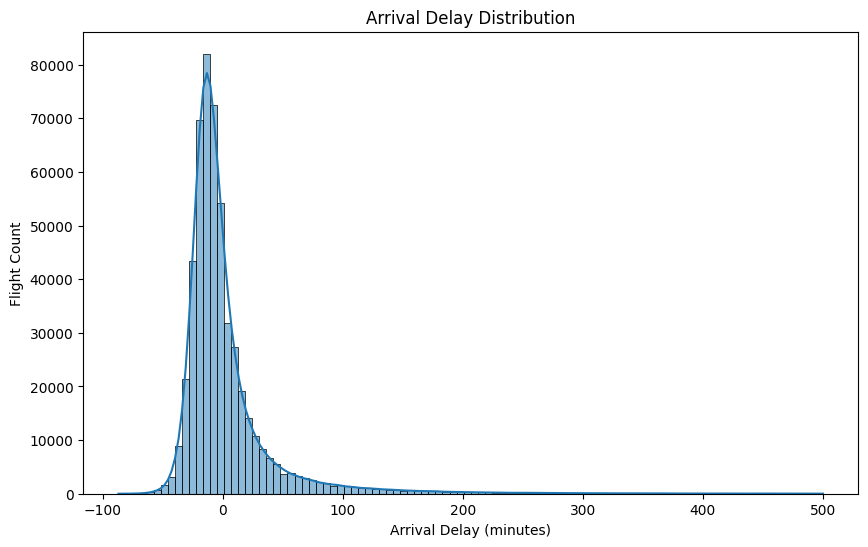

In [ ]:


plt.figure(figsize=(10, 6))
sns.histplot(df[df['ArrDelay'] <= 500].ArrDelay.dropna(), bins=100, kde=True)

plt.title('Arrival Delay Distribution')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Flight Count')
plt.show()

In [32]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,DayofMonth,DayOfWeek,DepTime,CRSDepTime,DepDelay,ArrTime,CRSArrTime,ArrDelay,Flight_Number_Reporting_Airline,AirTime,Distance,Cancelled,Diverted
DayofMonth,1.000000,-0.057654,-0.017485,-0.012467,-0.079262,0.013442,0.006502,-0.091441,0.001896,-0.020652,-0.022029,-0.041537,-0.006549
DayOfWeek,-0.057654,1.000000,0.005364,0.008163,0.023984,-0.006854,-0.000017,0.029420,-0.006038,0.011672,0.012570,-0.005643,0.004330
DepTime,-0.017485,0.005364,1.000000,0.960284,0.103802,0.654748,0.718452,0.096527,0.054967,-0.034955,-0.029256,0.009525,0.002658
CRSDepTime,-0.012467,0.008163,0.960284,1.000000,0.054927,0.633809,0.720363,0.047919,0.052158,-0.030233,-0.022125,0.005241,0.001392
DepDelay,-0.079262,0.023984,0.103802,0.054927,1.000000,0.017020,0.045564,0.963272,0.014759,0.002200,0.004565,0.042835,0.016077
ArrTime,0.013442,-0.006854,0.654748,0.633809,0.017020,1.000000,0.845903,0.016707,0.032432,0.026915,0.028199,NaN,-0.010428
CRSArrTime,0.006502,-0.000017,0.718452,0.720363,0.045564,0.845903,1.000000,0.039147,0.027994,0.034643,0.039949,-0.001935,0.004795
ArrDelay,-0.091441,0.029420,0.096527,0.047919,0.963272,0.016707,0.039147,1.000000,0.027531,-0.009257,-0.027209,NaN,NaN
Flight_Number_Reporting_Airline,0.001896,-0.006038,0.054967,0.052158,0.014759,0.032432,0.027994,0.027531,1.000000,-0.353784,-0.369397,0.034475,-0.001702
AirTime,-0.020652,0.011672,-0.034955,-0.030233,0.002200,0.026915,0.034643,-0.009257,-0.353784,1.000000,0.975775,NaN,NaN


SyntaxError: invalid syntax (3518897491.py, line 1)